<a href="https://colab.research.google.com/github/kinchittrivedi/Kaggle/blob/main/Real_estate_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Install/import fastai (usually pre-installed on Colab/Kaggle)
from fastai.tabular.all import *
import pandas as pd

In [2]:
# 1. Load data
df = pd.read_csv('real_estate_prices_pune.csv')

In [3]:
# 2. Drop City (constant now, no predictive value) and define column types
cat_names = ['Locality_Type', 'Property_Type', 'Furnishing']
cont_names = ['BHK', 'Bathrooms', 'Area_SqFt', 'Age_Years', 'Floor_No',
              'Total_Floors', 'Parking_Spaces', 'Distance_to_City_Center_KM']
procs = [Categorify, FillMissing, Normalize]

In [4]:
# 3. Random split
splits = RandomSplitter(valid_pct=0.2, seed=42)(range_of(df))

In [7]:
# 4. DataLoaders — key change: y_block=RegressionBlock instead of CategoryBlock
df['Price_Lakhs'] = df['Price_INR'] / 100000

dls = TabularDataLoaders.from_df(
    df,
    y_names="Price_Lakhs",
    y_block=RegressionBlock,   # <-- regression, not classification
    cat_names=cat_names,
    cont_names=cont_names,
    procs=procs,
    splits=splits,
    bs=64
)

<div></div>

epoch,train_loss,valid_loss,_rmse,mae,time
0,5031.271484,5390.312988,73.418755,66.117203,00:00
1,5240.233398,5336.159180,73.049019,66.084778,00:00
2,5372.548828,5236.443359,72.363274,66.168213,00:00
3,5498.857422,5162.166992,71.848221,66.702126,00:00
4,5349.011230,5002.990723,70.731827,66.678886,00:00
5,5260.605957,4851.429199,69.652199,67.113831,00:00
6,4974.189941,4501.477051,67.093048,66.490181,00:00
7,4662.737305,3976.510010,63.059574,62.247169,00:00
8,4383.205566,3694.937500,60.785999,59.797253,00:00
9,4049.176758,2457.738525,49.575584,47.333027,00:00


Better model found at epoch 0 with valid_loss value: 5390.31298828125.
Better model found at epoch 1 with valid_loss value: 5336.1591796875.
Better model found at epoch 2 with valid_loss value: 5236.443359375.
Better model found at epoch 3 with valid_loss value: 5162.1669921875.
Better model found at epoch 4 with valid_loss value: 5002.99072265625.
Better model found at epoch 5 with valid_loss value: 4851.42919921875.
Better model found at epoch 6 with valid_loss value: 4501.47705078125.
Better model found at epoch 7 with valid_loss value: 3976.510009765625.
Better model found at epoch 8 with valid_loss value: 3694.9375.
Better model found at epoch 9 with valid_loss value: 2457.738525390625.
Better model found at epoch 10 with valid_loss value: 1859.2763671875.
Better model found at epoch 11 with valid_loss value: 1329.1304931640625.
Better model found at epoch 12 with valid_loss value: 697.4210205078125.
Better model found at epoch 13 with valid_loss value: 387.52264404296875.
Better 

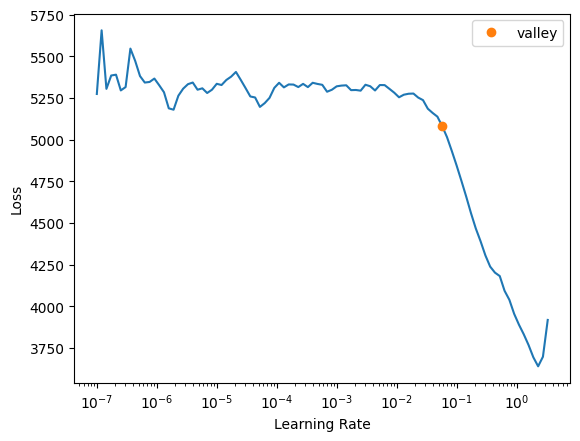

In [10]:
# 5. Model — metric changes too: use rmse or mae instead of accuracy
from fastai.callback.all import SaveModelCallback

learn = tabular_learner(dls, metrics=[rmse, mae])

# 6. Find learning rate
learn.lr_find()

# 7. Train
learn.fit_one_cycle(30, 1e-2, cbs=[SaveModelCallback(monitor='valid_loss')])

In [11]:
learn.show_results()

,Locality_Type,Property_Type,Furnishing,BHK,Bathrooms,Area_SqFt,Age_Years,Floor_No,Total_Floors,Parking_Spaces,Distance_to_City_Center_KM,Price_Lakhs,Price_Lakhs_pred
0,3.0,1.0,3.0,-1.466717,-1.157789,-1.664466,-1.511560,-0.195067,0.337956,-0.160506,-0.654602,21.570000,23.576353
1,2.0,2.0,3.0,1.283378,1.609834,1.601287,1.451121,0.890523,0.691219,-0.160506,-0.895597,99.669998,87.031128
2,3.0,2.0,3.0,-1.466717,-1.157789,-1.104393,0.147541,-1.144958,-0.957345,-1.470756,-0.790162,41.750000,42.594856
3,3.0,1.0,1.0,1.283378,1.609834,1.289016,0.503063,-1.009259,-0.133063,-1.470756,2.613891,100.419998,95.176224
4,3.0,2.0,2.0,-0.550019,-0.235248,-0.538275,-0.800516,-1.144958,-1.663872,-0.160506,-0.037053,70.339996,63.795349
5,2.0,2.0,3.0,1.283378,1.609834,1.315206,1.451121,-1.552054,-2.017136,1.149745,2.764513,73.419998,81.494919
6,3.0,1.0,1.0,1.283378,1.609834,1.289016,0.503063,-1.009259,-0.133063,-1.470756,2.613891,100.419998,95.176224
7,3.0,1.0,3.0,1.283378,1.609834,1.262825,-0.444995,1.569016,2.104275,-0.160506,-0.503981,88.599998,97.167206
8,3.0,1.0,3.0,-1.466717,-1.157789,-1.340107,0.621570,1.297619,0.808974,1.149745,-0.985970,29.320000,28.503378


In [12]:
preds, targets = learn.get_preds()
print(preds[:10])    # model's predicted prices (in lakhs)
print(targets[:10])  # actual prices (in lakhs)

tensor([[ 49.0483],
        [ 38.4411],
        [ 61.2128],
        [ 13.6735],
        [ 97.1672],
        [137.6581],
        [ 99.2124],
        [ 57.5610],
        [ 40.3656],
        [134.0483]])
tensor([[ 55.8000],
        [ 42.5700],
        [ 58.4800],
        [ 14.4000],
        [ 88.6000],
        [161.6300],
        [ 83.6500],
        [ 58.2900],
        [ 36.9000],
        [135.3000]])


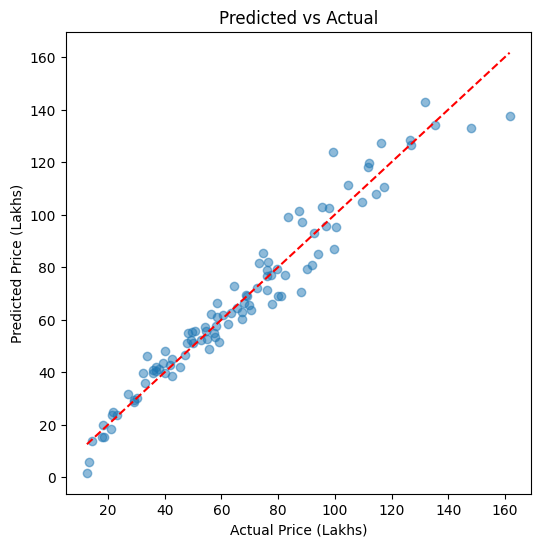

In [13]:
import matplotlib.pyplot as plt

preds, targets = learn.get_preds()
plt.figure(figsize=(6,6))
plt.scatter(targets, preds, alpha=0.5)
plt.plot([targets.min(), targets.max()], [targets.min(), targets.max()], 'r--')  # perfect prediction line
plt.xlabel('Actual Price (Lakhs)')
plt.ylabel('Predicted Price (Lakhs)')
plt.title('Predicted vs Actual')
plt.show()